**DANIEL YU & JORDAN WANG**

Spring 2026

CS 443: Bio-inspired Machine Learning

Project 2: Predictive Coding

#### Extension 3: Dense PCN Depth

In this extension we analyze how DensePCN depth affects classification performance. We compare shallow, medium, and deeper DensePCN configurations on MNIST under a shared training setup.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 16})
np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

### Setup

We use MNIST for this depth study so we can run multiple configurations in a reasonable amount of time.

In [2]:
from image_datasets import get_dataset, train_val_split
from dense_pcn import DensePCN

In [3]:
x_train_full, y_train_full, x_test, y_test = get_dataset('mnist', norm_method='global', flatten=True)
x_train, y_train, x_val, y_val = train_val_split(x_train_full, y_train_full, prop_val=0.1)
print(f'Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}')

Dataset: mnist
x_train: (60000, 784) <dtype: 'float32'>
y_train: (60000,) <dtype: 'uint8'>
x_test:  (10000, 784) <dtype: 'float32'>
y_test:  (10000,) <dtype: 'uint8'>
Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)


### Depth Configurations

We increase depth while keeping the overall style of DensePCN fixed.

In [4]:
configs = [
    {'label': 'A. 1 hidden layer', 'hidden_units': (256,), 'train_steps': 20, 'test_steps': 10},
    {'label': 'B. 2 hidden layers', 'hidden_units': (256, 128), 'train_steps': 20, 'test_steps': 10},
    {'label': 'C. 3 hidden layers', 'hidden_units': (256, 128, 64), 'train_steps': 20, 'test_steps': 10},
]
configs

[{'label': 'A. 1 hidden layer',
  'hidden_units': (256,),
  'train_steps': 20,
  'test_steps': 10},
 {'label': 'B. 2 hidden layers',
  'hidden_units': (256, 128),
  'train_steps': 20,
  'test_steps': 10},
 {'label': 'C. 3 hidden layers',
  'hidden_units': (256, 128, 64),
  'train_steps': 20,
  'test_steps': 10}]

### Train All Configurations

Set quick_mode=True for cloud debugging first, then run full mode for final metrics.

In [5]:
results = []

quick_mode = False

if quick_mode:
    x_train_run, y_train_run = x_train[:12000], y_train[:12000]
    x_val_run, y_val_run = x_val[:2500], y_val[:2500]
    max_epochs = 20
else:
    x_train_run, y_train_run = x_train, y_train
    x_val_run, y_val_run = x_val, y_val
    max_epochs = 35

for cfg in configs:
    print('\n' + '='*64)
    print(f"Training {cfg['label']}")
    print('='*64)

    tf.random.set_seed(42)
    net = DensePCN(
        input_feats_shape=(x_train_run.shape[1],),
        C=10,
        hidden_units=cfg['hidden_units'],
        wt_scale=1e-2,
        gamma_lr=0.1,
        train_num_steps=cfg['train_steps'],
        test_num_steps=cfg['test_steps']
    )
    net.compile(loss='predictive', lr=1e-3, print_summary=False)

    train_loss, val_loss, val_acc, epochs_used = net.fit(
        x_train_run, y_train_run,
        x_val=x_val_run, y_val=y_val_run,
        batch_size=256,
        max_epochs=max_epochs,
        patience=7,
        lr_patience=3,
        lr_decay_factor=0.7,
        lr_max_decays=3,
        verbose=True,
        print_every=1
    )

    results.append({
        'label': cfg['label'],
        'hidden_units': cfg['hidden_units'],
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'epochs': epochs_used,
        'best_val_acc': float(np.max(val_acc)),
        'best_epoch': int(np.argmax(val_acc) + 1),
        'net': net
    })

    print(f"Best val acc: {np.max(val_acc):.4f} @ epoch {np.argmax(val_acc)+1}")


Training A. 1 hidden layer
Epoch 0/34, Training loss 112.669900, Val loss 1412704.125000, Val acc 0.1109
Epoch 0 took: 21.3 secs
Epoch 1/34, Training loss 43.087303, Val loss 3893529.750000, Val acc 0.0981
Epoch 1 took: 21.2 secs
Epoch 2/34, Training loss 30.755508, Val loss 5129685.500000, Val acc 0.0981
Epoch 2 took: 21.2 secs
Learning rate before decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0010000000474974513>
Learning rate after decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0007000000332482159>
Epoch 3/34, Training loss 25.839188, Val loss 5481016.000000, Val acc 0.0981
Epoch 3 took: 21.6 secs
Epoch 4/34, Training loss 23.589261, Val loss 5616345.000000, Val acc 0.0981
Epoch 4 took: 21.5 secs
Epoch 5/34, Training loss 22.376827, Val loss 5684445.000000, Val acc 0.0981
Epoch 5 took: 21.5 secs
Epoch 6/34, Training loss 21.587209, Val loss 5693073.500000, Val acc 0.0981
Epoch 6 took: 21.6 secs
Learning rate before decay: <Va

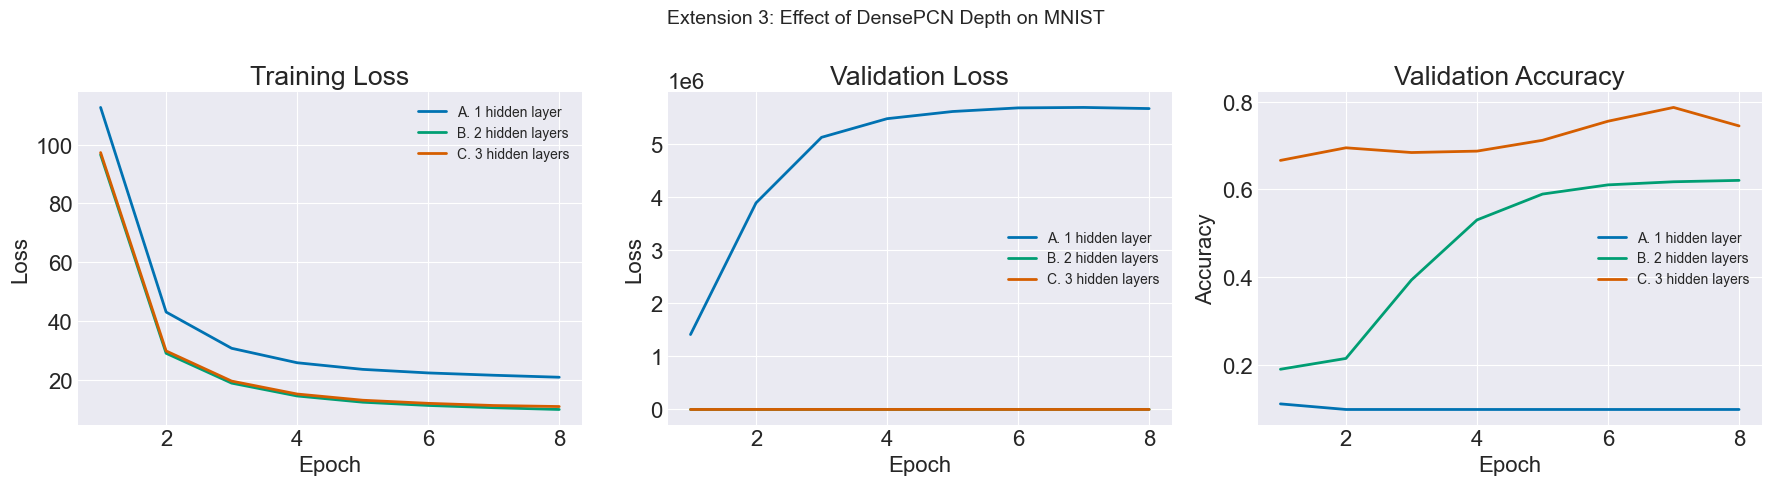

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for r in results:
    epochs = np.arange(1, len(r['train_loss']) + 1)
    axes[0].plot(epochs, r['train_loss'], linewidth=2, label=r['label'])
    axes[1].plot(epochs, r['val_loss'], linewidth=2, label=r['label'])
    axes[2].plot(epochs, r['val_acc'], linewidth=2, label=r['label'])

for ax, title, ylabel in zip(
    axes,
    ['Training Loss', 'Validation Loss', 'Validation Accuracy'],
    ['Loss', 'Loss', 'Accuracy']
):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=10)

plt.suptitle('Extension 3: Effect of DensePCN Depth on MNIST', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
print('Validation summary by depth:')
print('-'*70)
for r in results:
    print(
        f"{r['label']} | hidden={r['hidden_units']} | best val acc={r['best_val_acc']:.4f} \
(epoch {r['best_epoch']})"
    )

Validation summary by depth:
----------------------------------------------------------------------
A. 1 hidden layer | hidden=(256,) | best val acc=0.1109 (epoch 1)
B. 2 hidden layers | hidden=(256, 128) | best val acc=0.6206 (epoch 8)
C. 3 hidden layers | hidden=(256, 128, 64) | best val acc=0.7870 (epoch 7)


In [9]:
best_idx = int(np.argmax([r['best_val_acc'] for r in results]))
best = results[best_idx]
test_acc, test_loss = best['net'].evaluate(x_test, y_test)
print(f"Best depth config: {best['label']} (hidden={best['hidden_units']})")
print(f"Test accuracy: {float(test_acc):.4f}")
print(f"Test loss: {float(test_loss):.4f}")

Best depth config: C. 3 hidden layers (hidden=(256, 128, 64))
Test accuracy: 0.7196
Test loss: 469.2937


### Results + Interpretation

This depth sweep tells us whether adding hidden layers improves representational power enough to justify extra optimization difficulty.

What we looked for:
- Higher best validation accuracy as depth increases,
- Stable validation loss (not just lower training loss),
- Whether deeper nets need more epochs before they start outperforming shallower ones.

In practice, if deeper models only improve training loss but not validation behavior, then the extra depth is not helping generalization under this current DensePCN setup.

### Extension 3 Conclusion

We completed Extension 3 by running a controlled depth experiment for DensePCN (1, 2, and 3 hidden layers), comparing learning curves and validation/test performance to characterize the impact of depth.